## Set up data and model objects


In [1]:
import pandas as pd
import numpy as np
import mudata as md
from perturbo import run_svi, run_mcmc, perturbseq_guide_autonormal_turbo, perturbseq_model_turbo
import seaborn as sns
import matplotlib.pyplot as plt
import jax.numpy as jnp


test_ntcs = False

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


Set training configuration and access to data


### Load the data

(50k cells, takes ~30 seconds)


In [2]:
data_dir = "../../../../Data/gasperini_pilot"

mdata = md.read_h5mu(f"{data_dir}/gasperini_pilot_highMOI.h5mu")
# batch_size=None
mdata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [3]:
mdata["rna"].obs["log1p_guide_count"] = np.log1p(mdata["grna"].X.sum(axis=1))

In [4]:
mdata["grna"]

AnnData object with n_obs × n_vars = 47964 × 3115
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

In [5]:
# element = "ACTB_TSS"
# element = "ACTG1_TSS"
element_guides = [x for x in mdata["grna"].var_names if "_TSS" in x]
# element_guides = [x for x in mdata["grna"].var_names if "random" not in x and "scrambled" not in x]
# element_guides = mdata["grna"].varm["element_targeted"][element]
len(element_guides)

762

In [6]:
control_guides = [x for x in mdata["grna"].var_names if "random" in x or "scrambled" in x]
len(control_guides)
# control_guides = pd.Series(np.zeros(len(element_guides)), index=element_guides)
# control_guides[-50:] = 1
# control_guides

100

In [7]:
selected_guides = element_guides + control_guides
# selected_guides = mdata["grna"].var_names
len(selected_guides)

862

In [8]:
selected_cells = mdata["grna"][:, selected_guides].X.sum(axis=1) > 0
selected_cells.sum()

45053

In [9]:
if test_ntcs:
    grna_subset = mdata["grna"][:, selected_guides]
else:
    grna_subset = mdata["grna"][:, element_guides]
grna_subset = grna_subset[selected_cells, :]
grna_subset

View of AnnData object with n_obs × n_vars = 45053 × 762
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

In [10]:
mdata["rna"].var_names

Index(['AL627309.1', 'AL627309.5', 'AP006222.1', 'AL732372.2', 'AL669831.3',
       'MTND1P23', 'MTND2P28', 'MTCO1P12', 'AC114498.2', 'MTATP6P1',
       ...
       'TTTY14', 'TTTY10', 'AC024236.1', 'BX004987.1', 'AC011043.1',
       'AL592183.1', 'AC007325.4', 'AL354822.1', 'AC004556.3', 'AC240274.1'],
      dtype='object', length=16367)

In [11]:
# gene = "ACTB"
# genes = ["ACTB", "ACTG1", "MTND1P23"]
genes = sorted({x.split("_")[0] for x in element_guides})
genes = [x for x in genes if x in mdata["rna"].var_names]

len(genes)

373

In [12]:
# genes = mdata["rna"].var_names
rna_subset = mdata["rna"][:, genes]
rna_subset = rna_subset[selected_cells, :]
rna_subset

View of AnnData object with n_obs × n_vars = 45053 × 373
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size', 'log1p_guide_count'
    varm: 'element_tested'

In [13]:
cell_covariates = rna_subset.obs[["log_total_gene_count", "percent_mito", "log1p_guide_count"]].values
cell_covariates

array([[8.38571683, 0.0290571 , 3.55534816],
       [8.25478893, 0.02597587, 3.17805386],
       [8.20685643, 0.04274687, 2.19722462],
       ...,
       [8.13505391, 0.02120768, 3.66356158],
       [8.20412493, 0.02517777, 2.99573231],
       [8.52038808, 0.02861614, 2.56494927]])

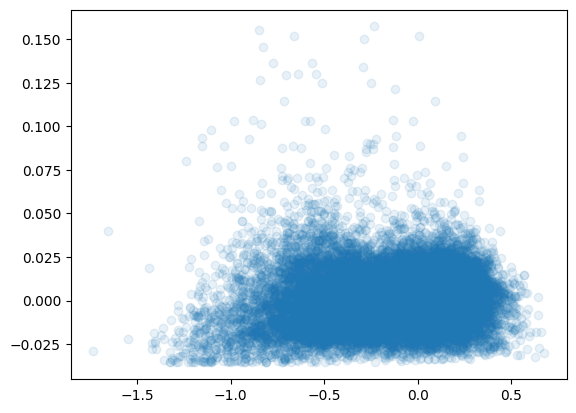

In [14]:
feature_means = cell_covariates.mean(axis=0)
feature_stds = cell_covariates.std(axis=0)
feature_medians = np.median(cell_covariates, axis=0)
feature_mads = np.median(np.abs(cell_covariates - feature_medians), axis=0)
cell_covariates_centered = cell_covariates - feature_medians
plt.scatter(x=cell_covariates_centered[:, 0], y=cell_covariates_centered[:, 1], alpha=0.1)

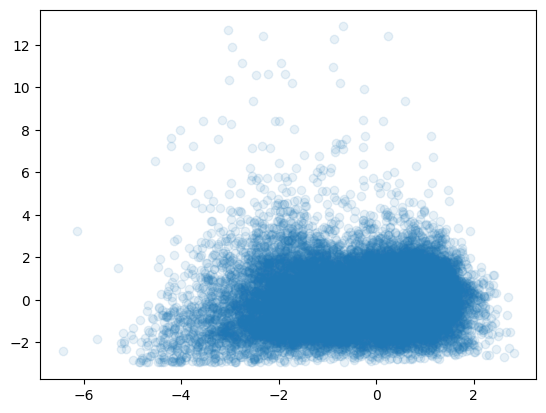

In [15]:
cell_covariates_z_scored = (cell_covariates - feature_means) / feature_stds

plt.scatter(x=cell_covariates_z_scored[:, 0], y=cell_covariates_z_scored[:, 1], alpha=0.1)

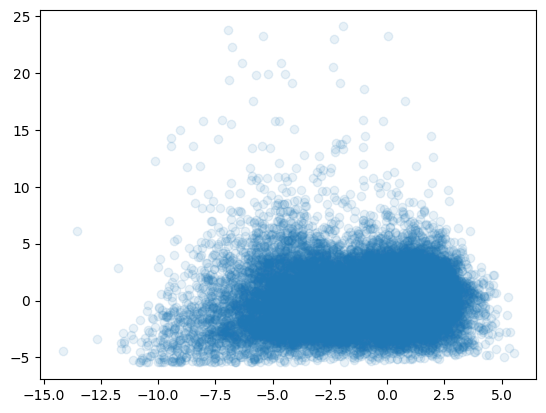

In [16]:
cell_covariates_robust_z_scored = (cell_covariates - feature_medians) / feature_mads
plt.scatter(x=cell_covariates_robust_z_scored[:, 0], y=cell_covariates_robust_z_scored[:, 1], alpha=0.1)

In [17]:
gene_obs = jnp.array(rna_subset.X.toarray()).astype(int)
guide_obs = jnp.array(grna_subset.X).astype(bool)
# guide_obs = guide_obs.at[:, 2:].set(0)
guide_obs.shape

(45053, 762)

In [18]:
targeted_in_subset = grna_subset.varm["element_targeted"].sum() > 0
selected_elements = targeted_in_subset[targeted_in_subset].index
guide_target_elements = grna_subset.varm["element_targeted"][selected_elements]
guide_target_elements

,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,WDR61_TSS,WSB1_TSS,XPO1_TSS,YWHAE_TSS,YWHAQ_TSS,ZC3H8_TSS,ZNF273_TSS,ZNF593_TSS,ZNHIT1_TSS,ZRANB2_TSS
ACTB_TSS|1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF593_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
ZNHIT1_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ZNHIT1_TSS|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ZRANB2_TSS|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [19]:
import pandas as pd
# gene_idx = 1

# n_plot_genes = min(4, len(genes))
# print(n_plot_genes)
# fig, axs = plt.subplots(3, n_plot_genes, sharex="col")


# # Control histogram
# for gene_idx in range(n_plot_genes):
#     max_count = gene_obs[:, gene_idx].max()
#     n_bins = min(int(max_count) + 1, 50)
#     hist_bins = np.linspace(0, max_count + 1, n_bins)
#     hist_bins = None
#     control_gene_obs = gene_obs[guide_obs.sum(axis=1) == 0, gene_idx].squeeze()
#     axs[0][gene_idx].hist(control_gene_obs, bins=hist_bins, density=True)
#     axs[0][gene_idx].axvline(control_gene_obs.mean(), color="black")
#     axs[0][gene_idx].set_ylabel("Density (control)")
#     axs[0][gene_idx].set_title(genes[gene_idx])

#     # Guide histograms
#     for i in range(2):
#         guide_gene_obs = gene_obs[guide_obs[:, i].astype(bool), gene_idx].squeeze()
#         axs[i + 1][gene_idx].axvline(guide_gene_obs.mean(), color="black")
#         # print(np.log2(guide_gene_obs.mean() / control_gene_obs.mean()))
#         axs[i + 1][gene_idx].hist(guide_gene_obs, bins=hist_bins, density=True)
#         axs[i + 1][gene_idx].set_ylabel(f"Density (guide {i})")
#         # axs[i + 1][gene_idx].set_title(f"")

#     axs[i + 1][gene_idx].set_xlabel("Gene counts per cell")
# plt.tight_layout()
# plt.show()

In [20]:
from itertools import product
import pandas as pd

df_combinations = pd.DataFrame(
    {"element": selected_elements, "value": 1}, index=selected_elements.str.split("_").str[0]
)
df_combinations
# Create a dataframe with every combination of row_indices and column_indices
# df_combinations = pd.DataFrame(0.0, index=mdata["rna"].var_names, columns=selected_elements)
# df_combinations = df_combinations.melt(value_name="value", var_name="element", ignore_index=False)
# df_combinations.loc[df_combinations.index == df_combinations["element"].str.split("_").str[0], "value"] = 1

,element,value
ACTB,ACTB_TSS,1
ACTG1,ACTG1_TSS,1
ACYP1,ACYP1_TSS,1
ADIPOR1,ADIPOR1_TSS,1
ALDH1A2,ALDH1A2_TSS,1
...,...,...
ZC3H8,ZC3H8_TSS,1
ZNF273,ZNF273_TSS,1
ZNF593,ZNF593_TSS,1
ZNHIT1,ZNHIT1_TSS,1


In [21]:
element_target_genes = (
    df_combinations.pivot(columns="element", values="value")
    .reindex(
        index=rna_subset.var_names,
        columns=guide_target_elements.columns,
    )
    .fillna(0)
)
# rna_subset.varm["target_gene"] = element_target_genes
# rna_subset.varm["target_gene"]
element_target_genes
# Set the values of the dataframe equal to one where the row index equals the column index up to the first "_" character
# df_combinations[df_combinations.index.str.split('_').str[0] == df_combinations.columns.str.split('_').str[0]] = 1
# df_combinations


# Display the dataframe
# df_combinations

,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,WDR61_TSS,WSB1_TSS,XPO1_TSS,YWHAE_TSS,YWHAQ_TSS,ZC3H8_TSS,ZNF273_TSS,ZNF593_TSS,ZNHIT1_TSS,ZRANB2_TSS
ACTB,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ADIPOR1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ALDH1A2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZC3H8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
ZNF273,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
ZNF593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
ZNHIT1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [22]:
rna_subset

View of AnnData object with n_obs × n_vars = 45053 × 373
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size', 'log1p_guide_count'
    varm: 'element_tested'

In [23]:
element_target_genes.sum()

ACTB_TSS       1.0
ACTG1_TSS      1.0
ACYP1_TSS      1.0
ADIPOR1_TSS    1.0
ALDH1A2_TSS    1.0
              ... 
ZC3H8_TSS      1.0
ZNF273_TSS     1.0
ZNF593_TSS     1.0
ZNHIT1_TSS     1.0
ZRANB2_TSS     1.0
Length: 381, dtype: float64

In [24]:
# assert element_target_genes.columns == mdata["grna"].varm["element_targeted"].columns

In [25]:
perturbseq_guide = perturbseq_guide_autonormal_turbo()
model_args = (gene_obs,)
model_kwargs = {
    "guide_obs": guide_obs,
    "guide_target_elements": jnp.array(guide_target_elements.values),  # all target same element
    "covariates": cell_covariates_robust_z_scored,
    "element_target_genes": jnp.array(element_target_genes.values).T,
    "likelihood": "NegBin",
    "subsample_size": 1024,
    "efficiency_alpha": 5,
    "efficiency_beta": 2,
}

svi_result = run_svi(
    model_args,
    model_kwargs,
    perturbseq_model_turbo,
    perturbseq_guide,
    lr=0.03,
    n_steps=2000,
)

100%|██████████| 2000/2000 [01:22<00:00, 24.22it/s, init loss: 112886984.0000, avg. loss [1901-2000]: 34773292.4000]


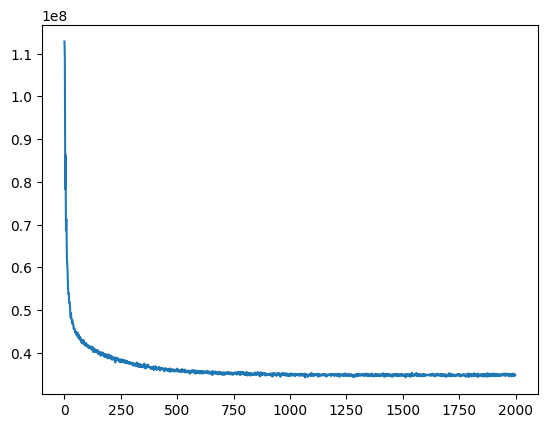

In [26]:
plt.plot(svi_result.losses)

In [27]:
params = svi_result.params
params.keys()

dict_keys(['covariate_weight_auto_loc', 'covariate_weight_auto_scale', 'dispersion_auto_loc', 'dispersion_auto_scale', 'efficiency_auto_loc', 'efficiency_auto_scale', 'factor_auto_loc', 'factor_auto_scale', 'loading_auto_loc', 'loading_auto_scale', 'log2_fold_change_auto_loc', 'log2_fold_change_auto_scale', 'mean_auto_loc', 'mean_auto_scale'])

In [28]:
# perturbseq_guide.median(params)

In [29]:
for k, v in perturbseq_guide.median(params).items():
    print(k, v.shape)

mean (373,)
dispersion (373,)
efficiency (762, 1)
log2_fold_change (381, 1)
factor (381, 1000)
loading (1000, 373)
covariate_weight (3, 373)


In [30]:
param_medians = perturbseq_guide.median(params)
gene_params_df = pd.DataFrame(
    {
        "gene": genes,
        "mean": param_medians["mean"],
        "dispersion": param_medians["dispersion"] if "dispersion" in param_medians else 1,
    }
)
gene_params_df

,gene,mean,dispersion
0,ACTB,20.906754,6.758012
1,ACTG1,8.075227,2.634267
2,ACYP1,1.356623,6.110374
3,ADIPOR1,2.720139,9.315562
4,ALDH1A2,2.592413,2.017963
...,...,...,...
368,ZC3H8,0.816976,6.336313
369,ZNF273,0.648527,2.846324
370,ZNF593,5.689634,7.838804
371,ZNHIT1,4.601991,13.567024


[]

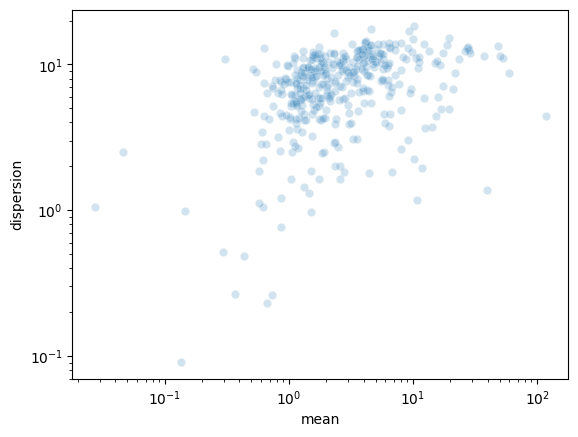

In [31]:
sns.scatterplot(gene_params_df, x="mean", y="dispersion", alpha=0.2)
plt.loglog()

In [32]:
# z_vals = params["log2_fold_change_auto_loc"] / params["log2_fold_change_auto_scale"]
# z_vals
perturbseq_guide.median(params)["factor"].max()

Array(1.0248748, dtype=float32)

(array([[  1.,   6.,  40., 158., 344., 315., 109.,  22.,   5.,   0.],
        [  4.,  22.,  53., 176., 271., 240., 162.,  52.,  15.,   5.],
        [  0.,  17.,  72., 175., 270., 230., 145.,  75.,  15.,   1.],
        [  6.,  12.,  73., 177., 272., 260., 139.,  50.,  10.,   1.],
        [  1.,   4.,  49., 178., 321., 300., 125.,  17.,   4.,   1.]]),
 array([-0.13315402, -0.10560454, -0.07805507, -0.05050559, -0.02295611,
         0.00459336,  0.03214284,  0.05969232,  0.0872418 ,  0.11479127,
         0.14234075]),
 <a list of 5 BarContainer objects>)

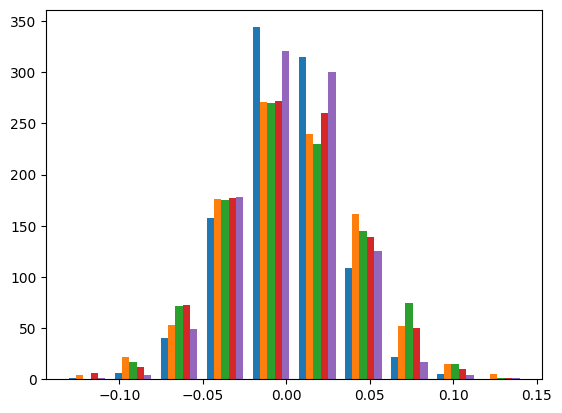

In [33]:
# plt.ecdf(perturbseq_guide.quantiles(params, 0.95)["log2_fold_change"].reshape(-1))
# plt.xlim(-1, 1)
# plt.show()
perturbseq_guide.median(params)["loading"].shape
plt.hist(perturbseq_guide.median(params)["loading"][:, :5].T)

(array([[  1.,   9.,  37.,  52., 116.,  87.,  58.,  15.,   6.,   0.],
        [  2.,   9.,  35.,  72., 112.,  90.,  34.,  19.,   6.,   2.],
        [  4.,  10.,  30.,  80.,  89.,  97.,  51.,  13.,   5.,   2.],
        [  1.,   5.,  24.,  98., 112.,  90.,  34.,  15.,   2.,   0.],
        [  2.,   4.,  33.,  78., 107.,  93.,  46.,  12.,   5.,   1.]]),
 array([-0.12678862, -0.10016508, -0.07354156, -0.04691803, -0.0202945 ,
         0.00632903,  0.03295256,  0.05957609,  0.08619962,  0.11282314,
         0.13944668]),
 <a list of 5 BarContainer objects>)

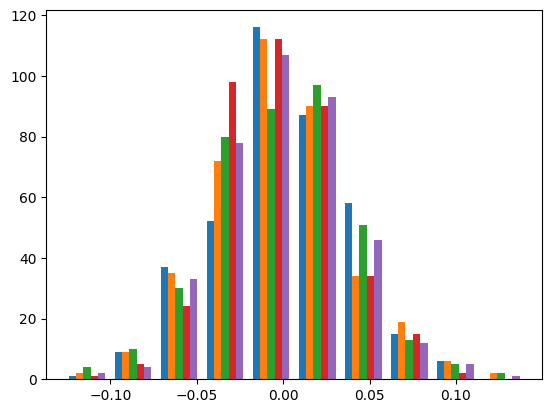

In [34]:
perturbseq_guide.median(params)["factor"].shape
plt.hist(perturbseq_guide.median(params)["factor"][:, :5].T)

(array([  2.,   5.,  13.,  64., 102., 155., 171., 143.,  73.,  34.]),
 array([0.66246337, 0.6756736 , 0.6888839 , 0.70209414, 0.71530443,
        0.72851467, 0.74172491, 0.7549352 , 0.76814544, 0.78135574,
        0.79456598]),
 <BarContainer object of 10 artists>)

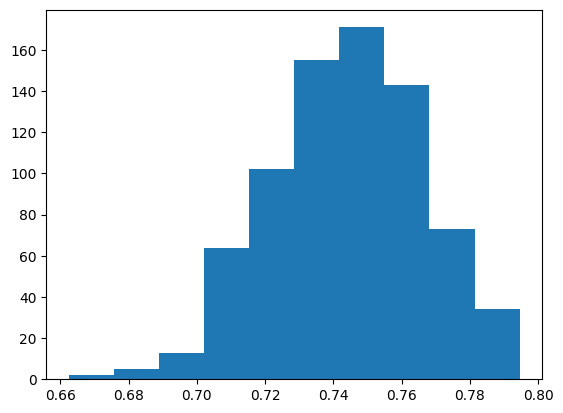

In [35]:
# perturbseq_guide.median(params)["loading"].shape
plt.hist(perturbseq_guide.median(params)["efficiency"].ravel())

# perturbseq_guide.median(params)["loading"]

[]

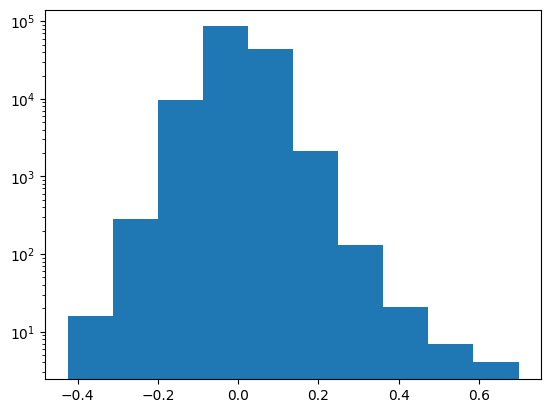

In [36]:
factorized_lfc = perturbseq_guide.median(params)["factor"] @ perturbseq_guide.median(params)["loading"]
plt.hist(factorized_lfc.ravel())
plt.semilogy()

In [37]:
perturbseq_guide.median(params)["factor"]

Array([[ 0.05506675,  0.03877096, -0.00970853, ...,  0.03515043,
        -0.03938658, -0.05796301],
       [ 0.00505972, -0.05890734,  0.00497587, ...,  0.00523407,
         0.04115874, -0.07954323],
       [ 0.07708304,  0.01652741,  0.01616805, ...,  0.0599089 ,
        -0.00702257, -0.04759179],
       ...,
       [ 0.00702625,  0.00540827, -0.00227461, ...,  0.02438172,
         0.00161645,  0.02294315],
       [ 0.00422916, -0.00498483, -0.02879176, ...,  0.01561349,
         0.03202069,  0.03586741],
       [-0.052065  , -0.01734357,  0.03405154, ...,  0.05387595,
         0.02845845,  0.05801121]], dtype=float32)

(array([  3.,   7.,  17.,  56.,  88., 124.,  51.,  27.,   6.,   2.]),
 array([-0.21540308, -0.17304525, -0.13068742, -0.08832958, -0.04597174,
        -0.0036139 ,  0.03874393,  0.08110177,  0.1234596 ,  0.16581744,
         0.20817527]),
 <BarContainer object of 10 artists>)

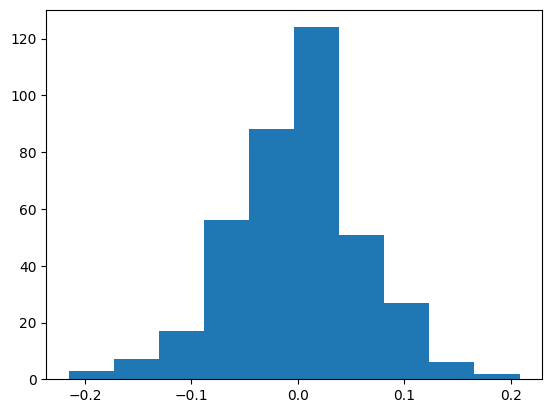

In [38]:
factorized_ontarget = jnp.sum(element_target_genes.values.T * factorized_lfc, axis=1)
plt.hist(factorized_ontarget)

(381, 1)

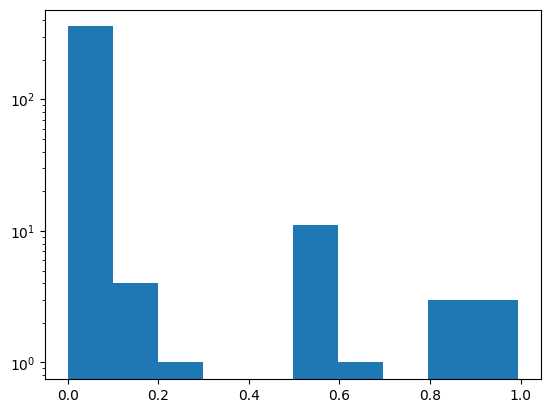

In [39]:
from scipy.stats import norm

alpha = 0.05
threshold = 0

factorized_ontarget = jnp.sum(element_target_genes.values.T * factorized_lfc, axis=1)
# if "log2_fold_change_auto_loc" in params:
mu = params["log2_fold_change_auto_loc"]
sigma = params["log2_fold_change_auto_scale"]
# else:
# sigma = jnp.sqrt(params["factor_auto_loc"]**2 * params["loading_auto_scale"]**2 + params["loading_auto_loc"]**2 * params["factor_auto_scale"])
p = norm.cdf(threshold, loc=mu, scale=sigma) - norm.cdf(-threshold, loc=mu, scale=sigma)
p = norm.sf(-threshold, loc=mu, scale=sigma)
# plt.hist(jnp.log(p+1e-10).ravel())
plt.hist(p.ravel())
plt.semilogy()
p.shape

In [40]:
negative_pairs = perturbseq_guide.quantiles(params, 1 - alpha)["log2_fold_change"][0, ...] < -threshold
positive_pairs = perturbseq_guide.quantiles(params, alpha)["log2_fold_change"][0, ...] > threshold
# significant_pairs = negative_pairs | positive_pairs
# significant_pairs = negative_pairs
# significant_pairs = significant_pairs & sufficiently_expressed
significant_pairs = p < alpha
significant_pairs.mean()

0.937007874015748

In [41]:
# element_idxs, gene_idxs = jnp.where(significant_pairs)
# significant_pairs_df = pd.DataFrame(
#     {"gene": [genes[i] for i in gene_idxs], "element": [selected_elements.values[i] for i in element_idxs]}
# )
# significant_pairs_df
# # for a, b in zip(*):
# # print(selected_elements.values[a], genes[b])
# # selected_elements

In [42]:
significant_pairs_df.query("gene=='EEF1A1'")

NameError: name 'significant_pairs_df' is not defined

In [ ]:
if test_ntcs:
    significant_pairs_df[significant_pairs_df["element"].str.contains("random|scrambled", regex=True)].value_counts(
        "gene"
    )

[]

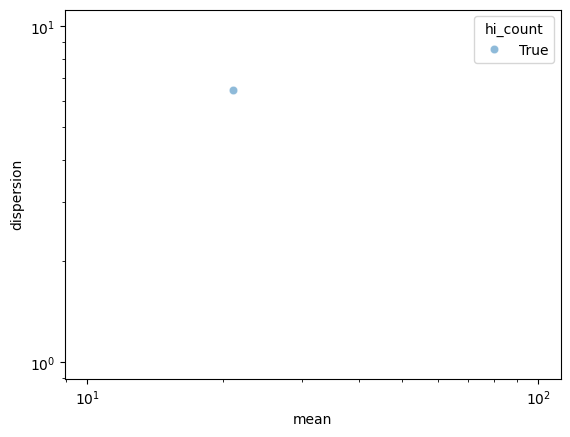

In [ ]:
sns.scatterplot(
    gene_params_df.merge(significant_pairs_df.value_counts("gene").reset_index()).assign(
        hi_count=lambda x: x["count"] > 5
    ),
    x="mean",
    y="dispersion",
    hue="hi_count",
    alpha=0.5,
)
plt.loglog()
# significant_pairs_df.value_counts("gene").reset_index()

In [ ]:
significant_pairs_df.value_counts("gene")

gene
ACTB    360
Name: count, dtype: int64

In [ ]:
significant_pairs_df.value_counts("element").head(20)

element
ACTB_TSS       1
RBMX_TSS       1
RBBP4_TSS      1
RAN_TSS        1
RABGGTB_TSS    1
RAB7A_TSS      1
PYCR2_TSS      1
PTTG1_TSS      1
PTP4A2_TSS     1
PSMG4_TSS      1
PSMG2_TSS      1
PSMG1_TSS      1
PSMB6_TSS      1
PSMA7_TSS      1
PSMA1_TSS      1
PRR13_TSS      1
PRPS1_TSS      1
PRPF38A_TSS    1
PRKCB_TSS      1
PRKAR2B_TSS    1
Name: count, dtype: int64

In [ ]:
np.mean(significant_pairs_df["gene"] == significant_pairs_df["element"].str.split("_").str[0])
# n_ontarget/len(signifi)

0.002777777777777778